In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

import joblib

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("IRIS.csv")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['species'].value_counts())

Dataset Shape: (150, 5)

Columns:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

Data Types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Class Distribution:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [4]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


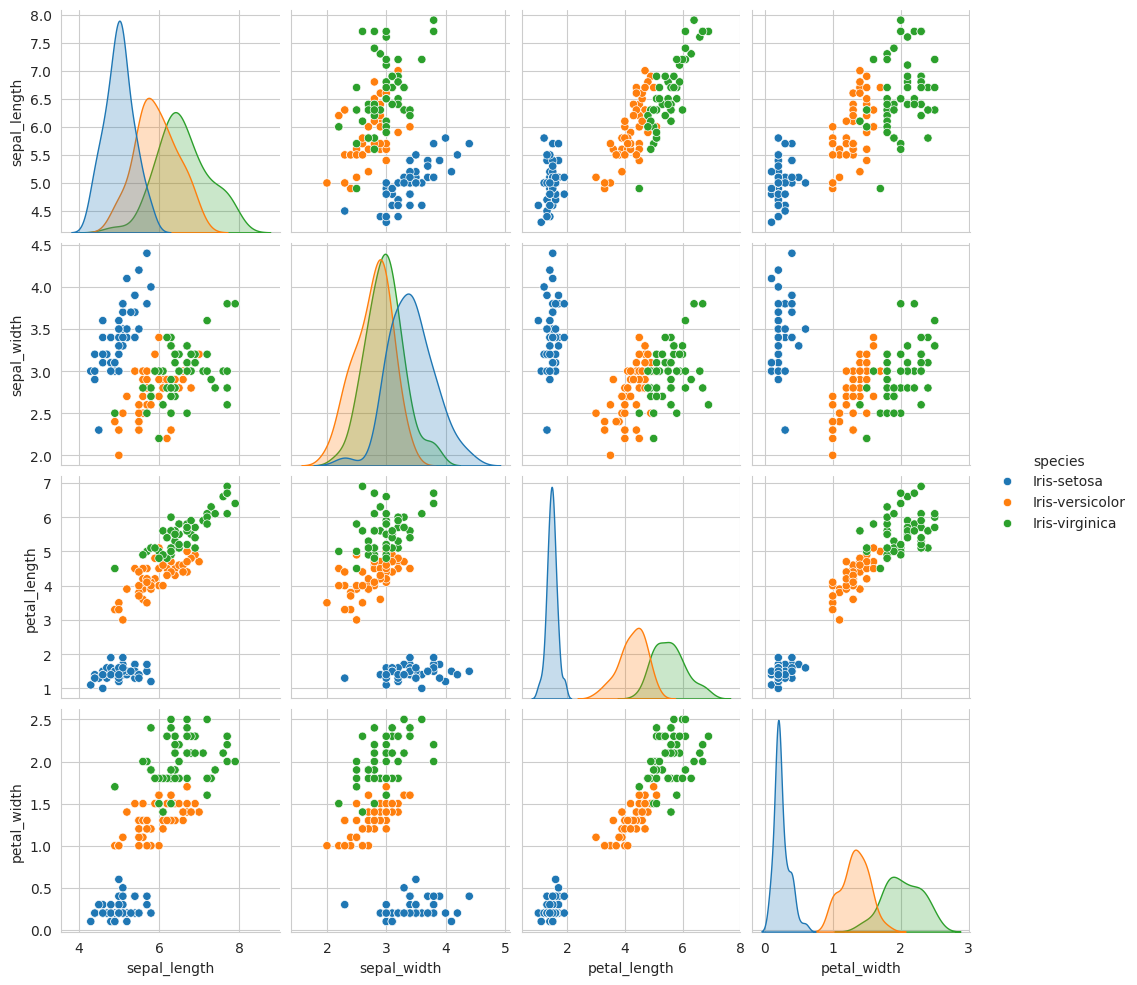

In [5]:
sns.pairplot(df, hue="species")
plt.show()

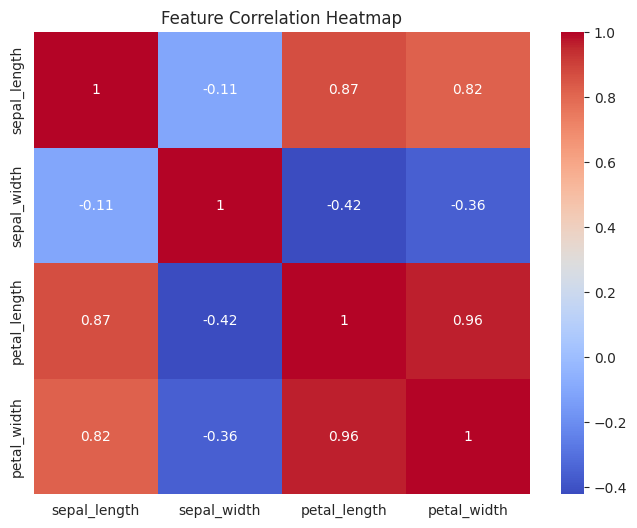

In [6]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop("species", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

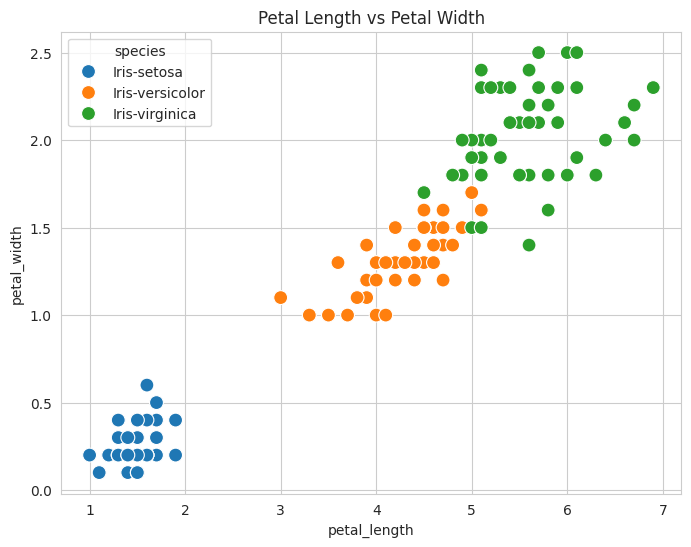

In [7]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="petal_length",
    y="petal_width",
    hue="species",
    s=100
)

plt.title("Petal Length vs Petal Width")
plt.show()

In [8]:
X = df.drop("species", axis=1)
y = df["species"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 120
Testing Samples: 30


In [10]:
models = {

    "k-NN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

Model: k-NN

Accuracy : 0.9333333333333333
Precision: 0.9444444444444445
Recall   : 0.9333333333333333

Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



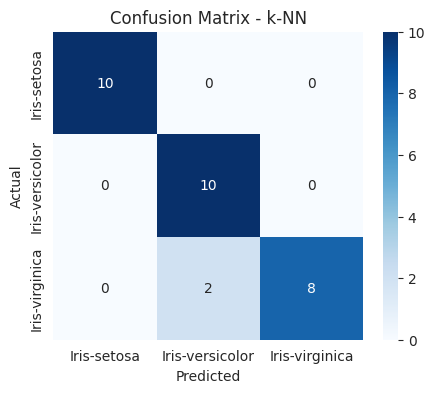

Model: Logistic Regression

Accuracy : 0.9333333333333333
Precision: 0.9333333333333333
Recall   : 0.9333333333333333

Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



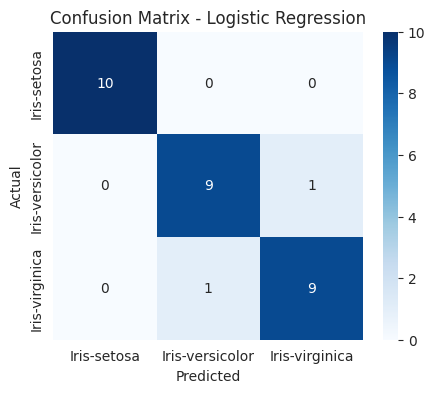

Model: Decision Tree

Accuracy : 0.9333333333333333
Precision: 0.9333333333333333
Recall   : 0.9333333333333333

Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



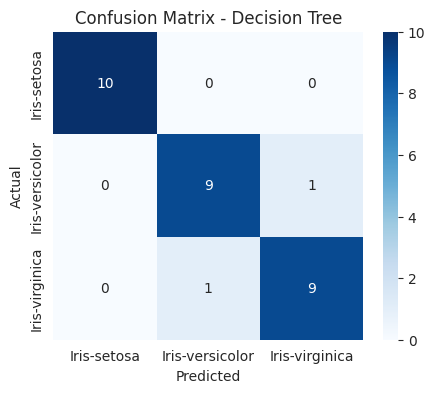

In [11]:
results = []

best_model = None
best_accuracy = 0
best_model_name = ""

for name, model in models.items():

    print("="*50)
    print("Model:", name)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    print("\nAccuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=np.unique(y),
        yticklabels=np.unique(y)
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    results.append([
        name,
        accuracy,
        precision,
        recall
    ])

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_model_name = name

In [12]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall"
    ]
)

results_df.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

results_df

,Model,Accuracy,Precision,Recall
0,k-NN,0.933333,0.944444,0.933333
1,Logistic Regression,0.933333,0.933333,0.933333
2,Decision Tree,0.933333,0.933333,0.933333


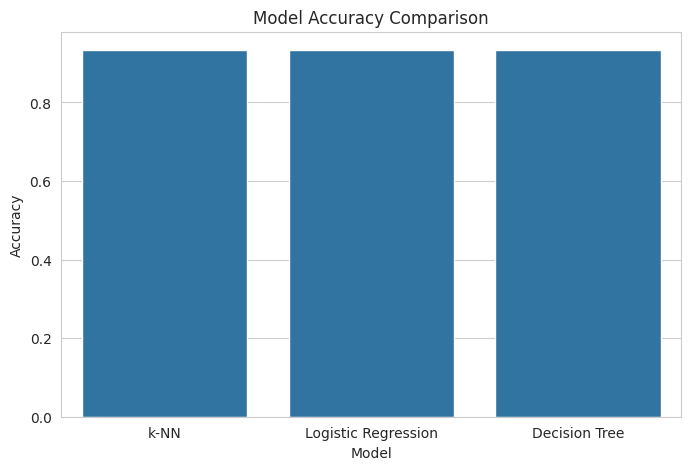

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.show()

In [14]:
print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy)

Best Model: k-NN
Best Accuracy: 0.9333333333333333


In [15]:
joblib.dump(
    best_model,
    "iris_best_model.joblib"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [16]:
loaded_model = joblib.load(
    "iris_best_model.joblib"
)

In [17]:
sample = pd.DataFrame({

    "sepal_length":[5.1],
    "sepal_width":[3.5],
    "petal_length":[1.4],
    "petal_width":[0.2]

})

prediction = loaded_model.predict(sample)

print("Predicted Species:", prediction[0])

Predicted Species: Iris-setosa
